# BERT + Optuna PetFinder

Versión robusta para entrenar DistilBERT con búsqueda de hiperparámetros y dejar predicciones listas para integrar con LightGBM.

Salida clave para integración:

```text
work/optuna_artifacts/bert_test_predictions.joblib
```

Este notebook reutiliza `test_petids.joblib`, por lo que el test será el mismo que LightGBM.


In [2]:
# ============================================================
# BERT + Optuna PetFinder - versión robusta para integración con LightGBM
#
# Objetivo:
# 1) Leer train.csv desde tu ruta real.
# 2) Reutilizar test_petids.joblib para compartir el mismo test con LightGBM.
# 3) Entrenar DistilBERT con búsqueda de hiperparámetros mediante Optuna.
# 4) Guardar el mejor modelo Hugging Face con save_pretrained().
# 5) Guardar bert_test_predictions.joblib para integrarlo por PetID.
# 6) Generar métricas, gráficos y tablas para explicar resultados.
#
# Entradas esperadas:
#   C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\train\train.csv
#
# Salidas principales:
#   work/optuna_artifacts/test_petids.joblib
#   work/optuna_artifacts/bert_test_predictions.joblib
#   work/models_bert_optuna/best_model/
#   work/bert_optuna_results/
# ============================================================

from pathlib import Path
import json
import math
import random
import gc
import warnings

import numpy as np
import pandas as pd
from joblib import dump, load

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    cohen_kappa_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
)

import torch
from torch.utils.data import DataLoader
from torch.optim import AdamW

from datasets import Dataset, DatasetDict

from transformers import (
    DistilBertTokenizerFast,
    DataCollatorWithPadding,
    AutoModelForSequenceClassification,
    get_scheduler,
)

from tqdm.auto import tqdm

try:
    import optuna
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "No está instalado optuna. Instálalo con:\n"
        "conda activate ldi2_cuda2\n"
        "python -m pip install optuna"
    ) from exc




c:\Users\Kevin\anaconda3\envs\ldi2_cuda2\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
# ============================================================
# 1. CONFIGURACIÓN
# ============================================================

warnings.filterwarnings("ignore")

SEED = 42
TEST_SIZE = 0.20
NUM_LABELS = 5
CLASS_LABELS = list(range(NUM_LABELS))

# Configuración pensada para tu GPU de 4 GB.
# Optuna probará algunos de estos valores.
N_TRIALS = 5

# Para una prueba rápida, deja 5.
# Para TP final, si tienes tiempo, puedes subir a 10 o 15.

MODEL_CHECKPOINT = "distilbert-base-uncased"
MODEL_NAME = "06_BERT_optuna"
MODEL_VERSION = "1.0"

# Tu ruta real del proyecto
BASE_DIR = Path(r"C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction")

PATH_TO_TRAIN = BASE_DIR / "train" / "train.csv"

WORK_DIR = BASE_DIR / "work"
PATH_TO_ARTIFACTS = WORK_DIR / "optuna_artifacts"
PATH_TO_MODELS = WORK_DIR / "models_bert_optuna"
RESULTS_DIR = WORK_DIR / "bert_optuna_results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

for p in [WORK_DIR, PATH_TO_ARTIFACTS, PATH_TO_MODELS, RESULTS_DIR, FIGURES_DIR, TABLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Este archivo debe ser compartido con LightGBM.
PATH_TO_TEST_IDS = PATH_TO_ARTIFACTS / "test_petids.joblib"

# SQLite con ruta absoluta, para evitar el problema de "../work/db.sqlite3".
OPTUNA_DB_PATH = RESULTS_DIR / "bert_optuna_study.sqlite3"
OPTUNA_STORAGE_URL = f"sqlite:///{OPTUNA_DB_PATH.as_posix()}"
OPTUNA_STUDY_NAME = f"{MODEL_NAME}_{MODEL_VERSION}"

BEST_MODEL_DIR = PATH_TO_MODELS / "best_model"
BEST_TRIAL_MODEL_DIR = PATH_TO_MODELS / "best_trial_model"

PATH_BERT_TEST_PREDS = PATH_TO_ARTIFACTS / "bert_test_predictions.joblib"
PATH_BERT_OOF_LIKE_PREDS = PATH_TO_ARTIFACTS / "bert_validation_predictions.joblib"

PATH_BERT_METRICS = RESULTS_DIR / "bert_optuna_metrics.json"
PATH_OPTUNA_TRIALS_CSV = TABLES_DIR / "optuna_trials.csv"
PATH_PER_CLASS_CSV = TABLES_DIR / "bert_per_class_metrics.csv"
PATH_TEST_PREVIEW = TABLES_DIR / "bert_test_predictions_preview.csv"

# Control de texto.
USE_NAME_IN_TEXT = True
USE_TABULAR_CONTEXT_AS_TEXT = True

# Si True, agrega columnas estructuradas como texto:
# "Age: 3 Type: 1 Gender: 2 ..."
# Esto suele mejorar BERT porque le da contexto que no está en Description.




In [4]:
# ============================================================
# 2. UTILIDADES GENERALES
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Benchmark suele acelerar cuando los tamaños son parecidos.
    torch.backends.cudnn.benchmark = True


def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def save_current_figure(filename):
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Gráfico guardado: {path}")


def read_train_csv(path):
    if not path.exists():
        raise FileNotFoundError(f"No encontré el archivo: {path}")

    df = pd.read_csv(path, sep=";", encoding="latin1")

    if len(df.columns) == 1:
        df = pd.read_csv(path, sep=",", encoding="latin1")

    required = {"PetID", "Description", "AdoptionSpeed"}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas obligatorias: {missing}")

    return df


def normalize_probabilities(probs):
    probs = np.asarray(probs, dtype=float)
    probs = np.nan_to_num(probs, nan=0.0, posinf=0.0, neginf=0.0)
    probs = np.clip(probs, 0.0, None)

    row_sums = probs.sum(axis=1, keepdims=True)
    zero_rows = row_sums.squeeze() == 0

    if np.any(zero_rows):
        probs[zero_rows, :] = 1.0 / probs.shape[1]
        row_sums = probs.sum(axis=1, keepdims=True)

    return probs / row_sums


def adjacent_accuracy(y_true, y_pred, tolerance=1):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred) <= tolerance))


def multiclass_brier_score(y_true, probs, num_classes=5):
    y_onehot = np.eye(num_classes)[np.asarray(y_true, dtype=int)]
    return float(np.mean(np.sum((probs - y_onehot) ** 2, axis=1)))


def safe_log_loss(y_true, probs):
    try:
        return float(log_loss(y_true, probs, labels=CLASS_LABELS))
    except Exception:
        return np.nan


def expected_class_from_probs(probs):
    classes = np.arange(probs.shape[1])
    return probs @ classes


def calculate_metrics(y_true, probs, model_name="BERT"):
    probs = normalize_probabilities(probs)
    y_true = np.asarray(y_true, dtype=int)
    y_pred = probs.argmax(axis=1)
    expected = expected_class_from_probs(probs)

    return {
        "model": model_name,
        "n": int(len(y_true)),
        "qwk": float(cohen_kappa_score(y_true, y_pred, weights="quadratic")),
        "kappa_unweighted": float(cohen_kappa_score(y_true, y_pred)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "mae_class": float(mean_absolute_error(y_true, y_pred)),
        "rmse_class": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "mae_expected_class": float(mean_absolute_error(y_true, expected)),
        "rmse_expected_class": float(math.sqrt(mean_squared_error(y_true, expected))),
        "adjacent_accuracy_1": adjacent_accuracy(y_true, y_pred, tolerance=1),
        "adjacent_accuracy_2": adjacent_accuracy(y_true, y_pred, tolerance=2),
        "log_loss": safe_log_loss(y_true, probs),
        "brier_multiclass": multiclass_brier_score(y_true, probs, NUM_LABELS),
        "mean_confidence": float(probs.max(axis=1).mean()),
    }




In [5]:
# ============================================================
# 3. PREPARACIÓN DE DATOS
# ============================================================

def build_text_column(df):
    """
    Crea una columna text para BERT.

    Mejora respecto al BERT simple:
    además de Description, puede agregar Name y algunas variables tabulares
    convertidas a texto. Esto permite que BERT use más contexto sin necesitar
    un modelo multimodal/tabular especial.
    """
    df = df.copy()

    df["Description"] = df["Description"].fillna("").astype(str)

    pieces = []

    if USE_NAME_IN_TEXT and "Name" in df.columns:
        name = df["Name"].fillna("").astype(str)
        pieces.append("Name: " + name)

    pieces.append("Description: " + df["Description"])

    if USE_TABULAR_CONTEXT_AS_TEXT:
        candidate_cols = [
            "Type", "Age", "Breed1", "Breed2", "Gender",
            "Color1", "Color2", "Color3",
            "MaturitySize", "FurLength",
            "Vaccinated", "Dewormed", "Sterilized",
            "Health", "Quantity", "Fee", "State",
            "VideoAmt", "PhotoAmt"
        ]

        for col in candidate_cols:
            if col in df.columns:
                pieces.append(f" {col}: " + df[col].fillna(-1).astype(str))

    text = pieces[0]
    for p in pieces[1:]:
        text = text + " " + p

    df["text"] = text
    df["labels"] = df["AdoptionSpeed"].astype(int)

    return df


def create_or_load_split(df):
    """
    Usa test_petids.joblib si existe.
    Si no existe, crea un split nuevo y lo guarda.
    """
    if PATH_TO_TEST_IDS.exists():
        print(f"Cargando test_ids existentes desde: {PATH_TO_TEST_IDS}")
        test_ids = load(PATH_TO_TEST_IDS)
        test_ids = list(test_ids)

        train_df = df[~df["PetID"].isin(test_ids)].copy()
        test_df = df[df["PetID"].isin(test_ids)].copy()

        if len(test_df) == 0:
            raise ValueError("test_petids.joblib existe, pero no coincide con los PetID del CSV.")

    else:
        print("No existe test_petids.joblib. Creando split nuevo...")
        train_df, test_df = train_test_split(
            df,
            test_size=TEST_SIZE,
            random_state=SEED,
            stratify=df["AdoptionSpeed"]
        )

        test_ids = test_df["PetID"].tolist()
        dump(test_ids, PATH_TO_TEST_IDS)

    return train_df.reset_index(drop=True), test_df.reset_index(drop=True), test_ids


def build_hf_datasets(train_df, test_df):
    train_dataset = Dataset.from_pandas(
        train_df[["text", "labels"]].reset_index(drop=True),
        preserve_index=False,
    )

    test_dataset = Dataset.from_pandas(
        test_df[["text", "labels"]].reset_index(drop=True),
        preserve_index=False,
    )

    return DatasetDict({
        "train": train_dataset,
        "test": test_dataset,
    })


def tokenize_datasets(dataset, tokenizer, max_length):
    def tokenize_function(batch):
        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=max_length,
        )

    dataset_enc = dataset.map(
        tokenize_function,
        batched=True,
        remove_columns=["text"],
    )

    dataset_enc.set_format(
        "torch",
        columns=["input_ids", "attention_mask", "labels"],
    )

    return dataset_enc


def build_dataloaders(dataset_enc, tokenizer, batch_size):
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    train_dataloader = DataLoader(
        dataset_enc["train"],
        shuffle=True,
        batch_size=batch_size,
        collate_fn=data_collator,
    )

    eval_dataloader = DataLoader(
        dataset_enc["test"],
        shuffle=False,
        batch_size=batch_size,
        collate_fn=data_collator,
    )

    return train_dataloader, eval_dataloader




In [5]:
# ============================================================
# 4. ENTRENAMIENTO Y EVALUACIÓN
# ============================================================

def evaluate_model(model, dataloader, device, use_amp=True):
    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    total_loss = 0.0
    total_batches = 0

    amp_enabled = use_amp and device.type == "cuda"

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluando", leave=False):
            batch = {k: v.to(device) for k, v in batch.items()}

            with torch.cuda.amp.autocast(enabled=amp_enabled):
                outputs = model(**batch)
                loss = outputs.loss

            probs = torch.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)

            total_loss += float(loss.item())
            total_batches += 1

            all_probs.extend(probs.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(batch["labels"].detach().cpu().numpy())

    all_probs = np.asarray(all_probs)
    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)

    metrics = calculate_metrics(all_labels, all_probs, model_name="BERT")
    metrics["loss"] = total_loss / max(total_batches, 1)

    return metrics, all_probs, all_preds, all_labels


def train_one_trial(
    trial,
    dataset,
    tokenizer,
    train_df,
    test_df,
    device,
    trial_model_dir,
):
    """
    Entrena un trial independiente.
    Cada trial crea un modelo nuevo, evitando contaminación entre trials.
    """
    # Hiperparámetros seguros para 4 GB de VRAM.
    batch_size = trial.suggest_categorical("batch_size", [4, 8])
    max_length = trial.suggest_categorical("max_length", [128, 192, 256])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 6e-5, log=True)
    weight_decay = trial.suggest_float("weight_decay", 0.0, 0.15)
    num_epochs = trial.suggest_int("num_epochs", 2, 4)
    gradient_accumulation_steps = trial.suggest_categorical("gradient_accumulation_steps", [1, 2, 4])
    warmup_ratio = trial.suggest_float("warmup_ratio", 0.0, 0.10)

    use_amp = True

    print("\nTrial", trial.number)
    print({
        "batch_size": batch_size,
        "max_length": max_length,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "num_epochs": num_epochs,
        "gradient_accumulation_steps": gradient_accumulation_steps,
        "warmup_ratio": warmup_ratio,
    })

    dataset_enc = tokenize_datasets(dataset, tokenizer, max_length=max_length)
    train_dataloader, eval_dataloader = build_dataloaders(
        dataset_enc,
        tokenizer,
        batch_size=batch_size,
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=NUM_LABELS,
    )
    model.to(device)

    optimizer = AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    optimizer_steps_per_epoch = math.ceil(len(train_dataloader) / gradient_accumulation_steps)
    num_training_steps = num_epochs * optimizer_steps_per_epoch
    num_warmup_steps = int(num_training_steps * warmup_ratio)

    lr_scheduler = get_scheduler(
        "linear",
        optimizer=optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps,
    )

    amp_enabled = use_amp and device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)

    best_qwk = -999.0
    best_metrics = None
    best_probs = None
    best_preds = None
    best_labels = None
    best_epoch = None

    progress_bar = tqdm(total=num_epochs * len(train_dataloader), desc=f"Trial {trial.number}", leave=False)

    try:
        for epoch in range(1, num_epochs + 1):
            model.train()
            optimizer.zero_grad()

            train_loss_sum = 0.0
            train_batches = 0

            for step, batch in enumerate(train_dataloader):
                batch = {k: v.to(device) for k, v in batch.items()}

                with torch.cuda.amp.autocast(enabled=amp_enabled):
                    outputs = model(**batch)
                    loss = outputs.loss
                    loss_for_backward = loss / gradient_accumulation_steps

                scaler.scale(loss_for_backward).backward()

                train_loss_sum += float(loss.item())
                train_batches += 1

                is_update_step = (step + 1) % gradient_accumulation_steps == 0
                is_last_step = (step + 1) == len(train_dataloader)

                if is_update_step or is_last_step:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                    scaler.step(optimizer)
                    scaler.update()

                    lr_scheduler.step()
                    optimizer.zero_grad()

                progress_bar.update(1)

            train_loss = train_loss_sum / max(train_batches, 1)

            val_metrics, val_probs, val_preds, val_labels = evaluate_model(
                model,
                eval_dataloader,
                device,
                use_amp=use_amp,
            )

            val_qwk = val_metrics["qwk"]

            print(
                f"Trial {trial.number} | Epoch {epoch}/{num_epochs} | "
                f"Train loss {train_loss:.5f} | Val QWK {val_qwk:.5f} | "
                f"Val Acc {val_metrics['accuracy']:.5f}"
            )

            trial.report(val_qwk, step=epoch)

            if trial.should_prune():
                raise optuna.TrialPruned()

            if val_qwk > best_qwk:
                best_qwk = val_qwk
                best_metrics = val_metrics
                best_probs = val_probs
                best_preds = val_preds
                best_labels = val_labels
                best_epoch = epoch

                # Guardar mejor modelo del trial.
                this_trial_dir = trial_model_dir / f"trial_{trial.number}_best"
                this_trial_dir.mkdir(parents=True, exist_ok=True)
                model.save_pretrained(this_trial_dir)
                tokenizer.save_pretrained(this_trial_dir)

                trial.set_user_attr("best_epoch", int(best_epoch))
                trial.set_user_attr("model_dir", str(this_trial_dir))
                trial.set_user_attr("best_qwk", float(best_qwk))

        progress_bar.close()

        # Guardar métricas adicionales como attrs.
        if best_metrics is not None:
            for k, v in best_metrics.items():
                if isinstance(v, (int, float, np.integer, np.floating)) and not pd.isna(v):
                    trial.set_user_attr(k, float(v))

        return best_qwk

    except RuntimeError as e:
        progress_bar.close()
        msg = str(e).lower()

        if "out of memory" in msg or "cuda" in msg:
            print("Trial falló por memoria CUDA. Se poda el trial.")
            cleanup_cuda()
            raise optuna.TrialPruned()

        raise

    finally:
        progress_bar.close()
        del model
        cleanup_cuda()


def copy_best_model_from_study(study):
    """
    Copia/recarga el mejor modelo guardado durante el mejor trial.
    Para evitar dependencias de shutil sobre carpetas existentes, se carga y re-guarda.
    """
    best_trial = study.best_trial
    model_dir = best_trial.user_attrs.get("model_dir")

    if model_dir is None:
        raise ValueError("El mejor trial no tiene model_dir guardado.")

    model_dir = Path(model_dir)

    print("\nMejor trial:", best_trial.number)
    print("Mejor value/QWK:", study.best_value)
    print("Modelo del mejor trial:", model_dir)

    best_model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    best_tokenizer = DistilBertTokenizerFast.from_pretrained(model_dir)

    BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    best_model.save_pretrained(BEST_MODEL_DIR)
    best_tokenizer.save_pretrained(BEST_MODEL_DIR)

    print("Mejor modelo final guardado en:", BEST_MODEL_DIR)

    return best_model, best_tokenizer




In [6]:
# ============================================================
# 5. GUARDADO DE RESULTADOS
# ============================================================

def save_predictions_and_metrics(
    test_df,
    probabilities,
    predictions,
    labels,
    metrics,
    study,
):
    bert_test_predictions = pd.DataFrame({
        "PetID": test_df["PetID"].values,
        "AdoptionSpeed": test_df["AdoptionSpeed"].astype(int).values,
        "pred": list(probabilities),
        "bert_pred_score": list(probabilities),
        "bert_pred": predictions,
    })

    dump(bert_test_predictions, PATH_BERT_TEST_PREDS)
    dump(bert_test_predictions, PATH_BERT_OOF_LIKE_PREDS)

    preview = bert_test_predictions.copy()
    preview["pred"] = [np.asarray(x).round(6).tolist() for x in preview["pred"]]
    preview["bert_pred_score"] = [np.asarray(x).round(6).tolist() for x in preview["bert_pred_score"]]
    preview.to_csv(PATH_TEST_PREVIEW, index=False)

    precision, recall, f1, support = precision_recall_fscore_support(
        labels,
        predictions,
        labels=CLASS_LABELS,
        zero_division=0,
    )

    per_class = pd.DataFrame({
        "class": CLASS_LABELS,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support.astype(int),
    })
    per_class.to_csv(PATH_PER_CLASS_CSV, index=False)

    trials_df = study.trials_dataframe()
    trials_df.to_csv(PATH_OPTUNA_TRIALS_CSV, index=False)

    summary = {
        "metrics": metrics,
        "classification_report": classification_report(
            labels,
            predictions,
            labels=CLASS_LABELS,
            zero_division=0,
            output_dict=True,
        ),
        "confusion_matrix": confusion_matrix(labels, predictions, labels=CLASS_LABELS).tolist(),
        "best_trial_number": int(study.best_trial.number),
        "best_trial_value": float(study.best_value),
        "best_trial_params": study.best_trial.params,
        "best_trial_user_attrs": study.best_trial.user_attrs,
        "paths": {
            "best_model_dir": str(BEST_MODEL_DIR),
            "bert_test_predictions": str(PATH_BERT_TEST_PREDS),
            "test_ids": str(PATH_TO_TEST_IDS),
            "optuna_trials_csv": str(PATH_OPTUNA_TRIALS_CSV),
            "figures_dir": str(FIGURES_DIR),
        },
        "config": {
            "seed": SEED,
            "n_trials": N_TRIALS,
            "model_checkpoint": MODEL_CHECKPOINT,
            "use_name_in_text": USE_NAME_IN_TEXT,
            "use_tabular_context_as_text": USE_TABULAR_CONTEXT_AS_TEXT,
        }
    }

    with open(PATH_BERT_METRICS, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=4, ensure_ascii=False)

    print("\nArchivos guardados:")
    print(f"- Mejor modelo BERT:          {BEST_MODEL_DIR}")
    print(f"- Predicciones BERT test:     {PATH_BERT_TEST_PREDS}")
    print(f"- Preview CSV:                {PATH_TEST_PREVIEW}")
    print(f"- Métricas JSON:              {PATH_BERT_METRICS}")
    print(f"- Optuna trials CSV:          {PATH_OPTUNA_TRIALS_CSV}")
    print(f"- Per class metrics:          {PATH_PER_CLASS_CSV}")




In [7]:
# ============================================================
# 6. GRÁFICOS
# ============================================================

def plot_optuna_history(study):
    trials = [t for t in study.trials if t.value is not None]

    if len(trials) == 0:
        print("No hay trials completos para graficar historia Optuna.")
        return

    numbers = [t.number for t in trials]
    values = [t.value for t in trials]
    best_so_far = np.maximum.accumulate(values)

    plt.figure(figsize=(10, 5))
    plt.plot(numbers, values, marker="o", label="QWK del trial")
    plt.plot(numbers, best_so_far, marker="o", label="Mejor QWK acumulado")
    plt.title("Evolución de Optuna")
    plt.xlabel("Trial")
    plt.ylabel("Quadratic Weighted Kappa")
    plt.grid(True, alpha=0.3)
    plt.legend()
    save_current_figure("01_optuna_history.png")


def plot_param_importance_simple(study):
    """
    Intenta usar Optuna importance.
    Si falla, grafica correlaciones simples de parámetros numéricos.
    """
    try:
        importance = optuna.importance.get_param_importances(study)
        if importance:
            keys = list(importance.keys())[::-1]
            vals = [importance[k] for k in keys]

            plt.figure(figsize=(9, 5))
            plt.barh(keys, vals)
            plt.title("Importancia de hiperparámetros según Optuna")
            plt.xlabel("Importancia")
            save_current_figure("02_optuna_param_importance.png")
            return
    except Exception as e:
        print("No se pudo calcular importancia Optuna:", e)

    print("Se omite gráfico de importancia de hiperparámetros.")


def plot_trial_params_vs_qwk(study):
    df = study.trials_dataframe()

    if "value" not in df.columns:
        return

    candidate_cols = [
        c for c in df.columns
        if c.startswith("params_") and pd.api.types.is_numeric_dtype(df[c])
    ]

    for col in candidate_cols:
        plt.figure(figsize=(7, 5))
        plt.scatter(df[col], df["value"])
        plt.title(f"{col} vs QWK")
        plt.xlabel(col.replace("params_", ""))
        plt.ylabel("QWK")
        plt.grid(True, alpha=0.3)
        save_current_figure(f"03_{col}_vs_qwk.png".replace("params_", ""))


def plot_confusion_matrices(labels, predictions):
    cm = confusion_matrix(labels, predictions, labels=CLASS_LABELS)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm)
    plt.title("Matriz de confusión - BERT Optuna")
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.xticks(CLASS_LABELS)
    plt.yticks(CLASS_LABELS)
    plt.colorbar()

    for i in range(NUM_LABELS):
        for j in range(NUM_LABELS):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")

    save_current_figure("04_confusion_matrix_bert_optuna.png")

    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm_norm, vmin=0, vmax=1)
    plt.title("Matriz de confusión normalizada - BERT Optuna")
    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.xticks(CLASS_LABELS)
    plt.yticks(CLASS_LABELS)
    plt.colorbar()

    for i in range(NUM_LABELS):
        for j in range(NUM_LABELS):
            plt.text(j, i, f"{cm_norm[i, j]:.2f}", ha="center", va="center")

    save_current_figure("05_confusion_matrix_normalizada_bert_optuna.png")


def plot_distribution(labels, predictions):
    real_counts = pd.Series(labels).value_counts().reindex(CLASS_LABELS, fill_value=0).sort_index()
    pred_counts = pd.Series(predictions).value_counts().reindex(CLASS_LABELS, fill_value=0).sort_index()

    x = np.arange(NUM_LABELS)
    width = 0.35

    plt.figure(figsize=(9, 5))
    plt.bar(x - width / 2, real_counts.values, width, label="Real")
    plt.bar(x + width / 2, pred_counts.values, width, label="Predicho")
    plt.xticks(x, CLASS_LABELS)
    plt.title("Distribución real vs predicha - BERT Optuna")
    plt.xlabel("Clase")
    plt.ylabel("Cantidad")
    plt.legend()
    save_current_figure("06_distribucion_real_vs_predicha_bert_optuna.png")


def plot_confidence(labels, predictions, probabilities):
    conf = probabilities.max(axis=1)

    plt.figure(figsize=(9, 5))
    plt.hist(conf[predictions == labels], bins=20, alpha=0.6, label="Correctas")
    plt.hist(conf[predictions != labels], bins=20, alpha=0.6, label="Incorrectas")
    plt.title("Confianza BERT Optuna en aciertos vs errores")
    plt.xlabel("Confianza máxima")
    plt.ylabel("Cantidad")
    plt.legend()
    save_current_figure("07_confianza_bert_optuna.png")


def plot_error_distance(labels, predictions):
    dist = np.abs(np.asarray(labels) - np.asarray(predictions))
    counts = pd.Series(dist).value_counts().reindex(CLASS_LABELS, fill_value=0).sort_index()

    plt.figure(figsize=(8, 5))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Distancia ordinal del error - BERT Optuna")
    plt.xlabel("|clase real - clase predicha|")
    plt.ylabel("Cantidad")
    save_current_figure("08_distancia_ordinal_error_bert_optuna.png")


def plot_per_class_metrics(labels, predictions):
    precision, recall, f1, support = precision_recall_fscore_support(
        labels,
        predictions,
        labels=CLASS_LABELS,
        zero_division=0,
    )

    x = np.arange(NUM_LABELS)
    width = 0.25

    plt.figure(figsize=(10, 5))
    plt.bar(x - width, precision, width, label="Precision")
    plt.bar(x, recall, width, label="Recall")
    plt.bar(x + width, f1, width, label="F1")
    plt.xticks(x, CLASS_LABELS)
    plt.ylim(0, 1)
    plt.title("Métricas por clase - BERT Optuna")
    plt.xlabel("Clase")
    plt.ylabel("Valor")
    plt.legend()
    save_current_figure("09_metricas_por_clase_bert_optuna.png")


def generate_all_plots(study, labels, predictions, probabilities):
    plot_optuna_history(study)
    plot_param_importance_simple(study)
    plot_trial_params_vs_qwk(study)
    plot_confusion_matrices(labels, predictions)
    plot_distribution(labels, predictions)
    plot_confidence(labels, predictions, probabilities)
    plot_error_distance(labels, predictions)
    plot_per_class_metrics(labels, predictions)




In [8]:
# ============================================================
# 7. MAIN
# ============================================================

def main():
    set_seed(SEED)
    cleanup_cuda()

    print("Leyendo datos...")
    df = read_train_csv(PATH_TO_TRAIN)
    print("Dataset original:", df.shape)

    df = df.dropna(subset=["PetID", "AdoptionSpeed"]).reset_index(drop=True)
    df["AdoptionSpeed"] = df["AdoptionSpeed"].astype(int)

    df = build_text_column(df)

    print("\nCreando o cargando split compartido...")
    train_df, test_df, test_ids = create_or_load_split(df)

    print("Train:", train_df.shape)
    print("Test: ", test_df.shape)

    print("\nDistribución train:")
    print(train_df["AdoptionSpeed"].value_counts(normalize=True).sort_index())

    print("\nDistribución test:")
    print(test_df["AdoptionSpeed"].value_counts(normalize=True).sort_index())

    print("\nCargando tokenizer base...")
    tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_CHECKPOINT)

    print("Armando DatasetDict...")
    dataset = build_hf_datasets(train_df, test_df)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("\nDevice:", device)

    if device.type == "cuda":
        print("GPU:", torch.cuda.get_device_name(0))

    print("\nCreando estudio Optuna...")
    study = optuna.create_study(
        direction="maximize",
        storage=OPTUNA_STORAGE_URL,
        study_name=OPTUNA_STUDY_NAME,
        load_if_exists=True,
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=2,
            n_warmup_steps=1,
        ),
    )

    completed_before = len([t for t in study.trials if t.state.name == "COMPLETE"])
    print("Trials completos existentes:", completed_before)

    # Ejecutar solo los trials faltantes hasta N_TRIALS completos.
    remaining_trials = max(0, N_TRIALS - completed_before)

    print("Trials a ejecutar ahora:", remaining_trials)

    if remaining_trials > 0:
        def objective(trial):
            return train_one_trial(
                trial=trial,
                dataset=dataset,
                tokenizer=tokenizer,
                train_df=train_df,
                test_df=test_df,
                device=device,
                trial_model_dir=PATH_TO_MODELS / "trials",
            )

        study.optimize(objective, n_trials=remaining_trials, gc_after_trial=True)
    else:
        print("Ya existen suficientes trials completos. No se entrena de nuevo.")

    if len([t for t in study.trials if t.state.name == "COMPLETE"]) == 0:
        raise RuntimeError("No hay trials completos. Revisa errores de memoria o configuración.")

    best_model, best_tokenizer = copy_best_model_from_study(study)
    best_model.to(device)
    best_model.eval()

    # Evaluación final con los hiperparámetros del mejor trial.
    best_params = study.best_trial.params
    best_batch_size = int(best_params.get("batch_size", 8))
    best_max_length = int(best_params.get("max_length", 256))

    print("\nRecreando dataloaders con mejores parámetros:")
    print("best_batch_size:", best_batch_size)
    print("best_max_length:", best_max_length)

    dataset_enc = tokenize_datasets(dataset, best_tokenizer, max_length=best_max_length)
    _, eval_dataloader = build_dataloaders(dataset_enc, best_tokenizer, batch_size=best_batch_size)

    final_metrics, probabilities, predictions, labels = evaluate_model(
        best_model,
        eval_dataloader,
        device,
        use_amp=True,
    )

    print("\n================ RESULTADOS BERT OPTUNA ================")
    for k, v in final_metrics.items():
        print(f"{k}: {v}")

    print("\nClassification report:")
    print(classification_report(labels, predictions, digits=4, zero_division=0))

    print("\nMatriz de confusión:")
    print(confusion_matrix(labels, predictions, labels=CLASS_LABELS))

    save_predictions_and_metrics(
        test_df=test_df,
        probabilities=probabilities,
        predictions=predictions,
        labels=labels,
        metrics=final_metrics,
        study=study,
    )

    print("\nGenerando gráficos...")
    generate_all_plots(study, labels, predictions, probabilities)

    print("\nListo. BERT Optuna queda preparado para integración.")
    print("Archivo principal para integrar:", PATH_BERT_TEST_PREDS)
    print("Mejor modelo:", BEST_MODEL_DIR)

## Ejecutar entrenamiento con Optuna

Por defecto corre `N_TRIALS = 5`.  
Para una corrida final más fuerte, puedes subirlo a 10 o 15 si tienes tiempo.

El notebook no reentrena trials ya completos: si el estudio ya tiene trials completos, solo ejecuta los faltantes hasta llegar a `N_TRIALS`.


Leyendo datos...
Dataset original: (14993, 24)

Creando o cargando split compartido...
Cargando test_ids existentes desde: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\optuna_artifacts\test_petids.joblib
Train: (11994, 26)
Test:  (2999, 26)

Distribución train:
AdoptionSpeed
0    0.027347
1    0.206103
2    0.269301
3    0.217359
4    0.279890
Name: proportion, dtype: float64

Distribución test:
AdoptionSpeed
0    0.027342
1    0.206069
2    0.269090
3    0.217406
4    0.280093
Name: proportion, dtype: float64

Cargando tokenizer base...


Armando DatasetDict...

Device: cuda
GPU: NVIDIA GeForce RTX 2050

Creando estudio Optuna...


[I 2026-04-29 21:07:15,241] A new study created in RDB with name: 06_BERT_optuna_1.0


Trials completos existentes: 0
Trials a ejecutar ahora: 5

Trial 0
{'batch_size': 8, 'max_length': 256, 'learning_rate': 2.411405078110778e-05, 'weight_decay': 0.10021943237487876, 'num_epochs': 2, 'gradient_accumulation_steps': 2, 'warmup_ratio': 0.006865909702525441}


Map:   0%|          | 0/11994 [00:00<?, ? examples/s]

...

Mejor modelo final guardado en: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\models_bert_optuna\best_model

Recreando dataloaders con mejores parámetros:
best_batch_size: 4
best_max_length: 256


Map:   0%|          | 0/11994 [00:00<?, ? examples/s]

Map:   0%|          | 0/2999 [00:00<?, ? examples/s]

Evaluando:   0%|          | 0/750 [00:00<?, ?it/s]


================ RESULTADOS BERT OPTUNA ================
model: BERT
n: 2999
qwk: 0.30499919628470784
kappa_unweighted: 0.18072650971928106
accuracy: 0.3887962654218073
balanced_accuracy: 0.3067128586319801
f1_macro: 0.2957650224932923
f1_weighted: 0.3703618061594535
mae_class: 0.9899966655551851
rmse_class: 1.396537422433577
mae_expected_class: 0.9252278173360156
rmse_expected_class: 1.1176391814106261
adjacent_accuracy_1: 0.7152384128042681
adjacent_accuracy_2: 0.9133044348116038
log_loss: 1.3893973828342034
brier_multiclass: 0.7170329837444104
mean_confidence: 0.45083452842117183
loss: 1.3894156765937806

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        82
           1     0.3105    0.3382    0.3238       618
           2     0.3141    0.3705    0.3400       807
           3     0.4201    0.1856    0.2574       652
           4     0.4945    0.6393    0.5576       840

    accuracy                      

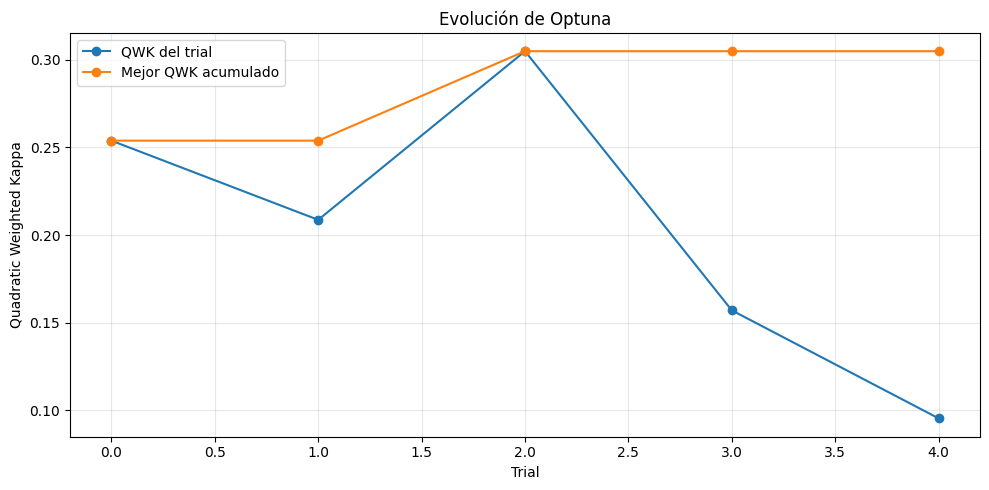

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\01_optuna_history.png


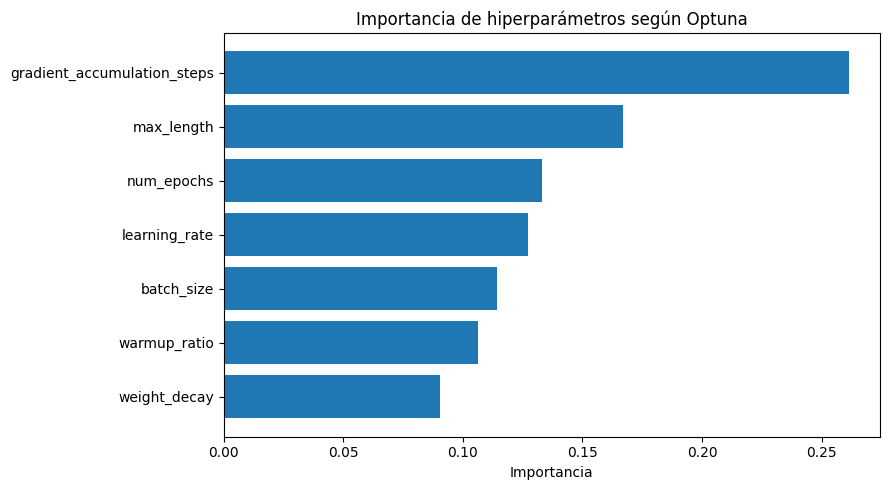

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\02_optuna_param_importance.png


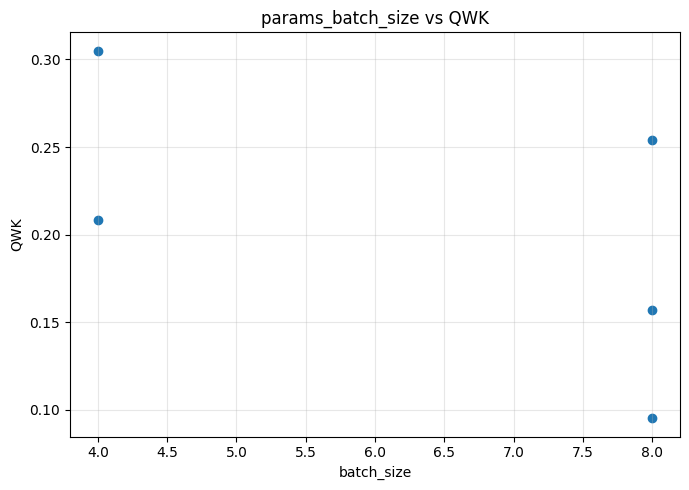

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\03_batch_size_vs_qwk.png


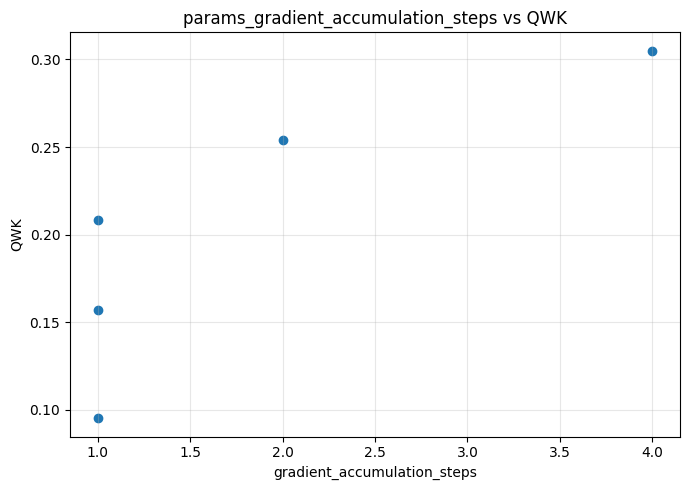

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\03_gradient_accumulation_steps_vs_qwk.png


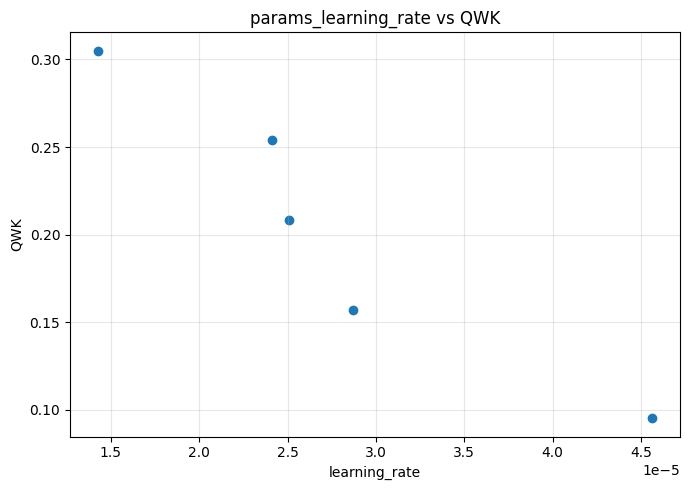

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\03_learning_rate_vs_qwk.png


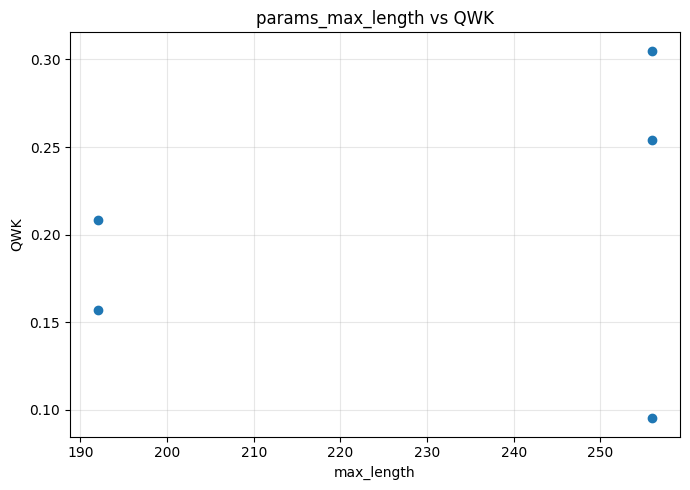

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\03_max_length_vs_qwk.png


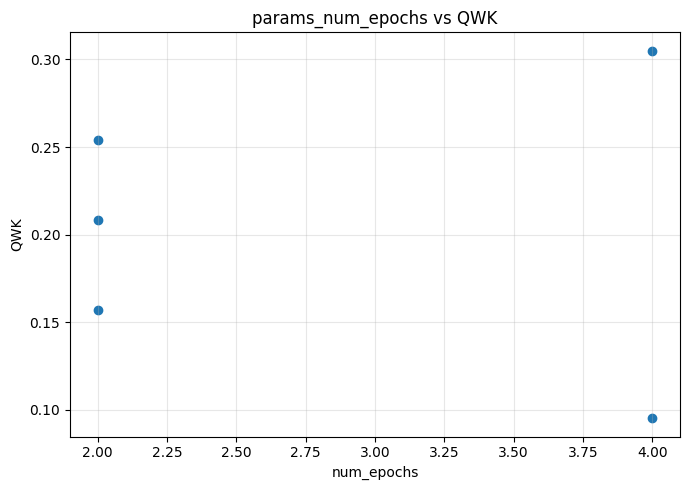

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\03_num_epochs_vs_qwk.png


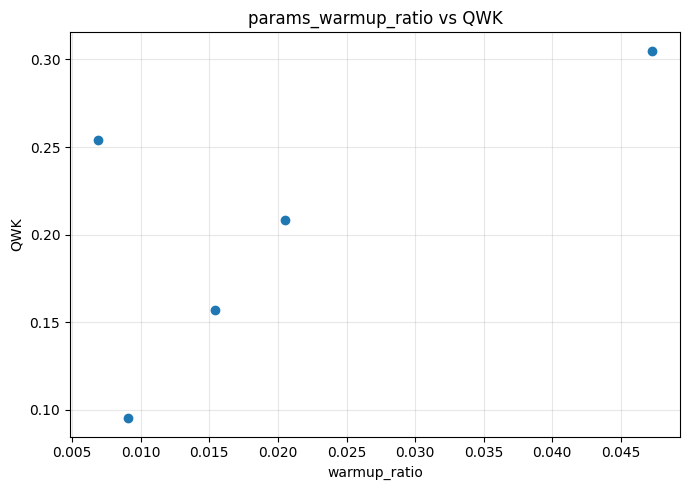

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\03_warmup_ratio_vs_qwk.png


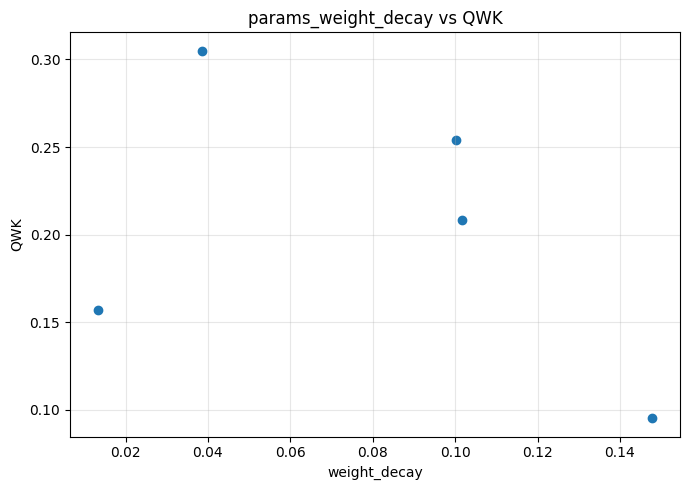

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\03_weight_decay_vs_qwk.png


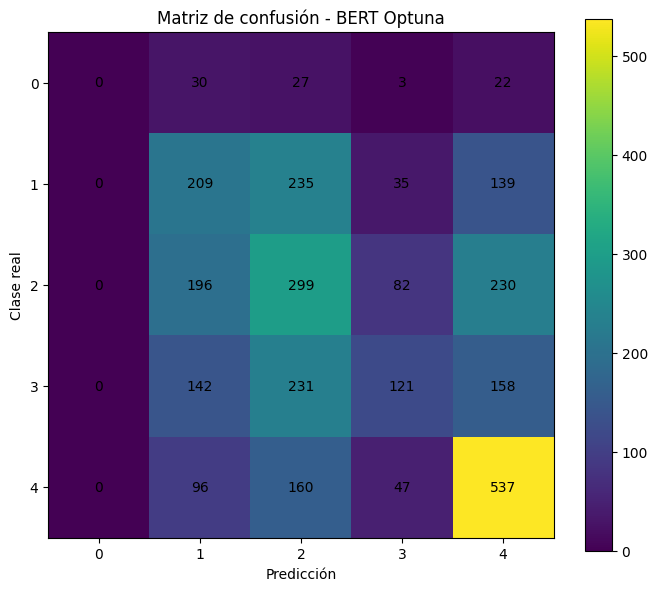

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\04_confusion_matrix_bert_optuna.png


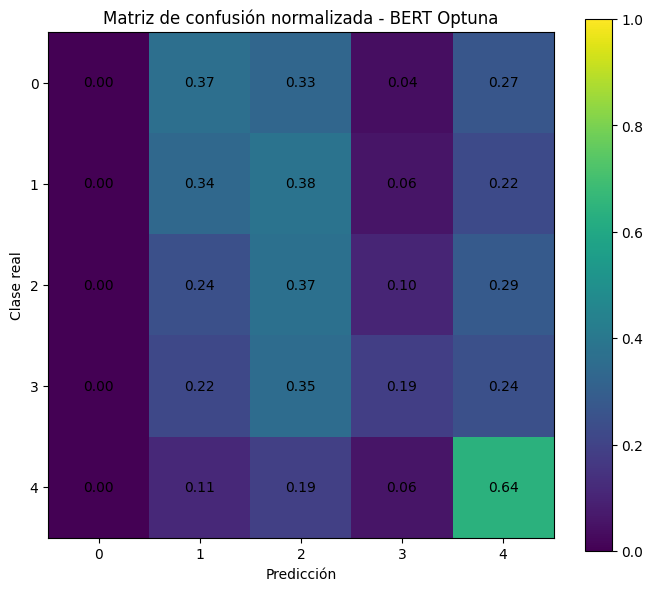

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\05_confusion_matrix_normalizada_bert_optuna.png


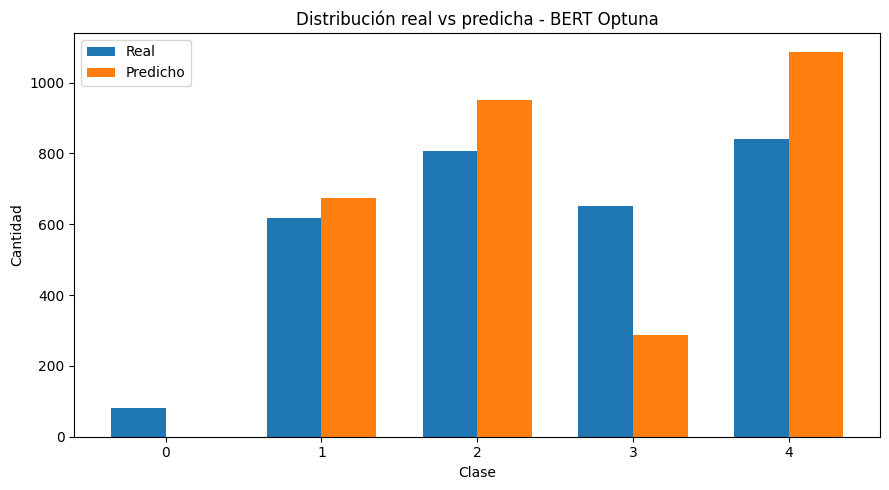

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\06_distribucion_real_vs_predicha_bert_optuna.png


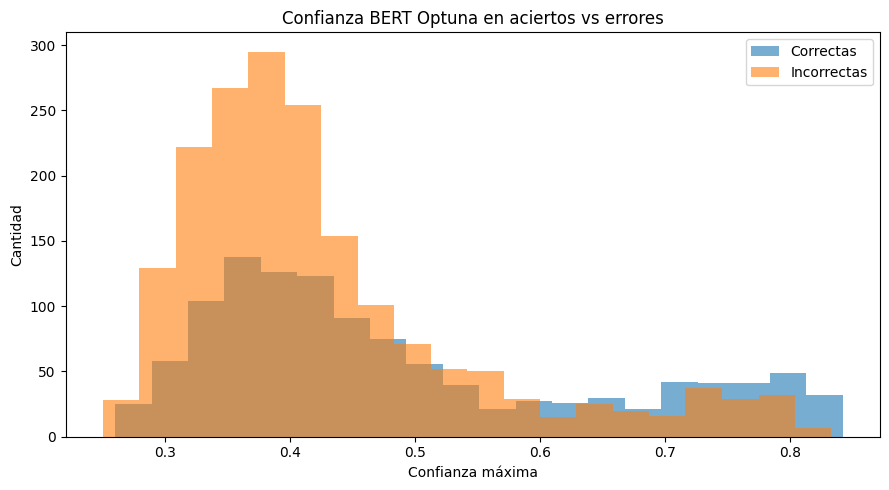

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\07_confianza_bert_optuna.png


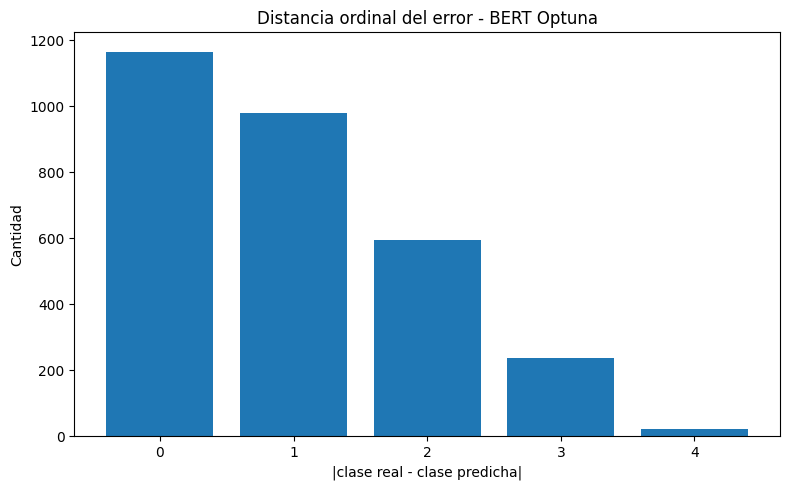

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\08_distancia_ordinal_error_bert_optuna.png


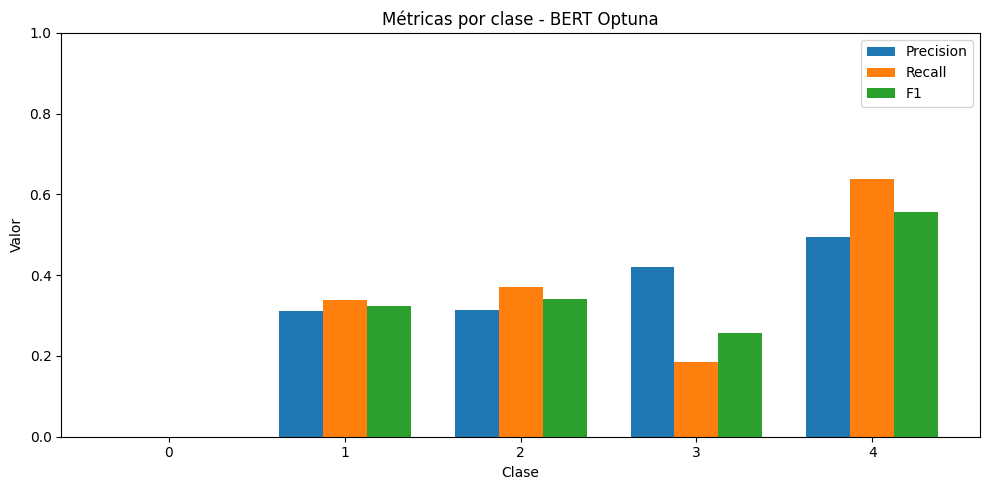

Gráfico guardado: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\bert_optuna_results\figures\09_metricas_por_clase_bert_optuna.png

Listo. BERT Optuna queda preparado para integración.
Archivo principal para integrar: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\optuna_artifacts\bert_test_predictions.joblib
Mejor modelo: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\models_bert_optuna\best_model


In [9]:
main()

## Cargar resultados ya generados

Ejecuta esta celda si ya entrenaste y solo quieres revisar resultados.


In [6]:
metrics = json.loads(PATH_BERT_METRICS.read_text(encoding="utf-8"))
trials_df = pd.read_csv(PATH_OPTUNA_TRIALS_CSV)
per_class_df = pd.read_csv(PATH_PER_CLASS_CSV)
bert_preds = load(PATH_BERT_TEST_PREDS)

print("Métricas finales:")
print(metrics["metrics"])

print("\nBest trial params:")
print(metrics["best_trial_params"])

print("\nTrials Optuna:")
display(trials_df)

print("\nMétricas por clase:")
display(per_class_df)

print("\nPredicciones:")
display(bert_preds.head())


Métricas finales:
{'model': 'BERT', 'n': 2999, 'qwk': 0.30499919628470784, 'kappa_unweighted': 0.18072650971928106, 'accuracy': 0.3887962654218073, 'balanced_accuracy': 0.3067128586319801, 'f1_macro': 0.2957650224932923, 'f1_weighted': 0.3703618061594535, 'mae_class': 0.9899966655551851, 'rmse_class': 1.396537422433577, 'mae_expected_class': 0.9252278173360156, 'rmse_expected_class': 1.1176391814106261, 'adjacent_accuracy_1': 0.7152384128042681, 'adjacent_accuracy_2': 0.9133044348116038, 'log_loss': 1.3893973828342034, 'brier_multiclass': 0.7170329837444104, 'mean_confidence': 0.45083452842117183, 'loss': 1.3894156765937806}

Best trial params:
{'batch_size': 4, 'max_length': 256, 'learning_rate': 1.4258172815311996e-05, 'weight_decay': 0.038677241681280734, 'num_epochs': 4, 'gradient_accumulation_steps': 4, 'warmup_ratio': 0.04729065822928341}

Trials Optuna:


,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_gradient_accumulation_steps,params_learning_rate,params_max_length,params_num_epochs,...,user_attrs_loss,user_attrs_mae_class,user_attrs_mae_expected_class,user_attrs_mean_confidence,user_attrs_model_dir,user_attrs_n,user_attrs_qwk,user_attrs_rmse_class,user_attrs_rmse_expected_class,state
0,0,0.253909,2026-04-29 21:07:15.257300,2026-04-29 21:15:55.625407,0 days 00:08:40.368107,8,2,0.000024,256,2,...,1.371786,1.009003,0.945214,0.393894,C:\Users\Kevin\Documents\GitHub Maestria\petfi...,2999.0,0.253909,1.421973,1.112125,COMPLETE
1,1,0.208679,2026-04-29 21:15:55.844759,2026-04-29 21:28:46.572386,0 days 00:12:50.727627,4,1,0.000025,192,2,...,1.402872,1.064355,0.961780,0.408635,C:\Users\Kevin\Documents\GitHub Maestria\petfi...,2999.0,0.208679,1.473564,1.141078,COMPLETE
2,2,0.304999,2026-04-29 21:28:46.801645,2026-04-29 21:47:46.499081,0 days 00:18:59.697436,4,4,0.000014,256,4,...,1.389416,0.989997,0.925228,0.450835,C:\Users\Kevin\Documents\GitHub Maestria\petfi...,2999.0,0.304999,1.396537,1.117639,COMPLETE
3,3,0.156990,2026-04-29 21:47:46.916957,2026-04-29 21:52:00.030412,0 days 00:04:13.113455,8,1,0.000029,192,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRUNED
4,4,0.095295,2026-04-29 21:52:00.202413,2026-04-29 21:56:41.094486,0 days 00:04:40.892073,8,1,0.000046,256,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PRUNED



Métricas por clase:


,class,precision,recall,f1,support
0,0,0.000000,0.000000,0.000000,82
1,1,0.310550,0.338188,0.323780,618
2,2,0.314076,0.370508,0.339966,807
3,3,0.420139,0.185583,0.257447,652
4,4,0.494475,0.639286,0.557632,840



Predicciones:


,PetID,AdoptionSpeed,pred,bert_pred_score,bert_pred
0,8e76c8e39,1,"[0.02882, 0.4133, 0.2947, 0.1831, 0.07996]","[0.02882, 0.4133, 0.2947, 0.1831, 0.07996]",1
1,6436c1a59,2,"[0.01514, 0.0309, 0.0951, 0.1416, 0.7173]","[0.01514, 0.0309, 0.0951, 0.1416, 0.7173]",4
2,988988d5b,1,"[0.0627, 0.2301, 0.2654, 0.1421, 0.2996]","[0.0627, 0.2301, 0.2654, 0.1421, 0.2996]",4
3,efbf1703a,2,"[0.03885, 0.3713, 0.3586, 0.1456, 0.0856]","[0.03885, 0.3713, 0.3586, 0.1456, 0.0856]",1
4,543130f60,4,"[0.01492, 0.0803, 0.138, 0.102, 0.665]","[0.01492, 0.0803, 0.138, 0.102, 0.665]",4


## Cargar modelo ya entrenado sin reentrenar

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = DistilBertTokenizerFast.from_pretrained(BEST_MODEL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_DIR)

model.to(device)
model.eval()

print("Modelo cargado desde:", BEST_MODEL_DIR)
print("Device:", device)
print("model.training:", model.training)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Modelo cargado desde: C:\Users\Kevin\Documents\GitHub Maestria\petfinder-adoption-prediction\work\models_bert_optuna\best_model
Device: cuda
model.training: False
